In [1]:
import os
import urllib.request
import zipfile


BASE_DIR = "/content/"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# MovieLens 20M dataset
MOVIELENS_URL = "https://files.grouplens.org/datasets/movielens/ml-20m.zip"
ZIP_PATH = os.path.join(RAW_DIR, "ml-20m.zip")
EXTRACT_DIR = os.path.join(RAW_DIR, "ml-20m")

# Download dataset
if not os.path.exists(ZIP_PATH):
    print("Downloading MovieLens 20M dataset...")
    urllib.request.urlretrieve(MOVIELENS_URL, ZIP_PATH)
    print("Download complete.")

# Extract dataset
if not os.path.exists(EXTRACT_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(RAW_DIR)
    print("Extraction complete.")

# Example file paths
RATINGS_FILE = os.path.join(EXTRACT_DIR, "ratings.csv")
MOVIES_FILE = os.path.join(EXTRACT_DIR, "movies.csv")
TAGS_FILE = os.path.join(EXTRACT_DIR, "tags.csv")

print("Dataset ready:")
print(RATINGS_FILE)
print(MOVIES_FILE)
print(TAGS_FILE)


Download complete.
Extracting dataset...
Extraction complete.
Dataset ready:
/content/data/raw/ml-20m/ratings.csv
/content/data/raw/ml-20m/movies.csv
/content/data/raw/ml-20m/tags.csv


In [ ]:
ratings = pd.read_csv(RATINGS_CSV, usecols=["userId", "movieId", "rating"])
print("Total rows:", len(ratings))
print("Total users:", ratings["userId"].nunique())
print("Total items:", ratings["movieId"].nunique())
print("Rating min/max:", ratings["rating"].min(), ratings["rating"].max())
ratings.head()


Total rows: 20000263
Total users: 138493
Total items: 26744
Rating min/max: 0.5 5.0


,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [ ]:
rng = np.random.default_rng(SEED)

all_users = ratings["userId"].unique()
total_users = all_users.size

# Start from MIN_USERS and increase if needed
k = MIN_USERS

while True:
    if k > total_users:
        k = total_users

    sampled_users = rng.choice(all_users, size=k, replace=False)
    sample = ratings[ratings["userId"].isin(sampled_users)].copy()

    n_users = sample["userId"].nunique()
    n_items = sample["movieId"].nunique()
    n_ratings = len(sample)

    print(f"Trying k={k} → users={n_users}, items={n_items}, ratings={n_ratings}")

    if (n_users >= MIN_USERS) and (n_items >= MIN_ITEMS) and (n_ratings >= MIN_RATINGS):
        break

    if k == total_users:
        raise RuntimeError("Could not satisfy constraints even using all users.")

    # Increase user sample size
    k = min(total_users, int(k * 1.1) + 1)


Trying k=10000 → users=10000, items=16979, ratings=1454360


In [ ]:
print("\nFINAL SAMPLE")
print("Users   :", sample["userId"].nunique())
print("Items   :", sample["movieId"].nunique())
print("Ratings :", len(sample))



FINAL SAMPLE
Users   : 10000
Items   : 16979
Ratings : 1454360


In [ ]:
# Number of ratings per user (n_u)
n_u = sample.groupby("userId")["rating"].count()

print("n_u computed")
print(n_u.head())
print("Total users in n_u:", n_u.shape[0])


n_u.to_csv("out/n_u.csv", header=["n_u"])

print("n_u saved to out/n_u.csv")


n_u computed
userId
1     175
55     30
71     45
77    100
85     69
Name: rating, dtype: int64
Total users in n_u: 10000
n_u saved to out/n_u.csv


In [ ]:
# Number of ratings per item (n_i)
n_i = sample.groupby("movieId")["rating"].count()

print("n_i computed")
print(n_i.head())
print("Total items in n_i:", n_i.shape[0])

# Save n_i to CSV
n_i.to_csv("out/n_i.csv", header=["n_i"])

print("n_i saved to out/n_i.csv")


n_i computed
movieId
1    3524
2    1580
3     894
4     199
5     867
Name: rating, dtype: int64
Total items in n_i: 16979
n_i saved to out/n_i.csv


In [ ]:
# Average rating per user (r̄_u)
rbar_u = sample.groupby("userId")["rating"].mean()

print("r̄_u computed")
print(rbar_u.head())
print("Total users in r̄_u:", rbar_u.shape[0])

# Save r̄_u to CSV
rbar_u.to_csv("out/rbar_u.csv", header=["rbar_u"])

print("r̄_u saved to out/rbar_u.csv")


r̄_u computed
userId
1     3.742857
55    4.166667
71    4.322222
77    3.605000
85    4.224638
Name: rating, dtype: float64
Total users in r̄_u: 10000
r̄_u saved to out/rbar_u.csv


In [ ]:
# Average rating per item (r̄_i)
rbar_i = sample.groupby("movieId")["rating"].mean()

print("r̄_i computed")
print(rbar_i.head())
print("Total items in r̄_i:", rbar_i.shape[0])

# Save r̄_i to CSV
rbar_i.to_csv("out/rbar_i.csv", header=["rbar_i"])

print("r̄_i saved to out/rbar_i.csv")


r̄_i computed
movieId
1    3.935017
2    3.238291
3    3.195190
4    2.859296
5    3.075548
Name: rating, dtype: float64
Total items in r̄_i: 16979
r̄_i saved to out/rbar_i.csv


In [ ]:
# Sort number of ratings per item in ascending order
n_i_sorted = n_i.sort_values(ascending=True)

print("Sorted n_i (ascending)")
print(n_i_sorted.head())
print("Total items:", n_i_sorted.shape[0])


Sorted n_i (ascending)
movieId
131260    1
78919     1
78913     1
78885     1
78858     1
Name: rating, dtype: int64
Total items: 16979


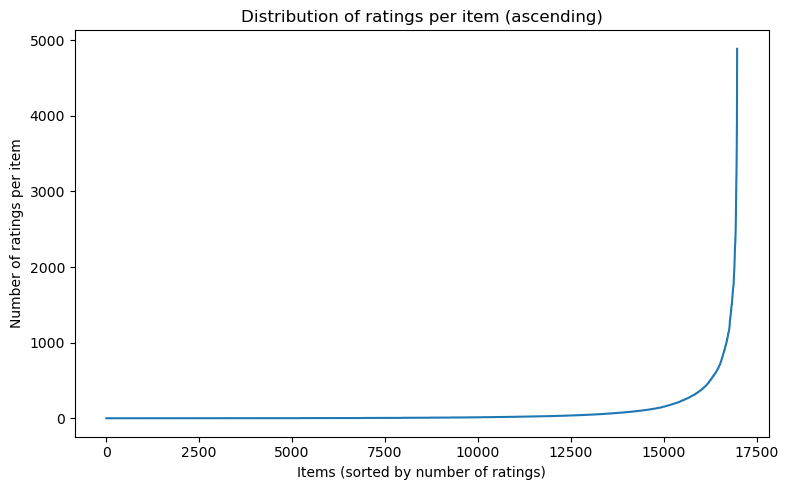

Plot saved to out/item_rating_count_distribution.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(n_i_sorted.values)
plt.xlabel("Items (sorted by number of ratings)")
plt.ylabel("Number of ratings per item")
plt.title("Distribution of ratings per item (ascending)")
plt.tight_layout()

plt.savefig("out/item_rating_count_distribution.png")
plt.show()

print("Plot saved to out/item_rating_count_distribution.png")


In [ ]:
# Sort items by average rating (ascending)
rbar_i_sorted = rbar_i.sort_values(ascending=True)

n_items = len(rbar_i_sorted)

# Percentile boundaries
bins = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 1.00]

group_id = {}

rank = 0
for item_id in rbar_i_sorted.index:
    rank += 1
    pct = rank / n_items

    g = 1
    while g <= 10 and pct > bins[g - 1]:
        g += 1
    if g > 10:
        g = 10

    group_id[item_id] = g

# Convert to Series
group_id = pd.Series(group_id, name="group_id")


In [ ]:
# Number of products per group
group_counts = group_id.value_counts().sort_index()

print("Number of products per group:")
print(group_counts)

# Save group assignment per item
group_id.to_csv("out/item_groups.csv", header=True)

# Save group counts
group_counts.to_csv("out/group_counts.csv", header=["num_products"])

print("Saved:")
print("- out/item_groups.csv")
print("- out/group_counts.csv")


Number of products per group:
1      169
2      679
3      849
4     1698
5     1698
6     1698
7     1698
8     1698
9     1698
10    5094
Name: group_id, dtype: int64
Saved:
- out/item_groups.csv
- out/group_counts.csv


In [ ]:
# Combine item counts with group assignment
item_group_stats = pd.DataFrame({
    "n_i": n_i,
    "group": group_id
})

# Total number of ratings in each group
group_total_ratings = item_group_stats.groupby("group")["n_i"].sum().sort_index()

print("Total number of ratings per group (G1..G10):")
print(group_total_ratings)


Total number of ratings per group (G1..G10):
group
1        245
2       8822
3      12169
4      47242
5     105361
6      77282
7     145285
8     202277
9     110095
10    745582
Name: n_i, dtype: int64


In [ ]:
# Order groups by total number of ratings (ascending)
group_total_ratings_sorted = group_total_ratings.sort_values(ascending=True)

print("\nGroups ordered by total ratings (ascending):")
print(group_total_ratings_sorted)

group_total_ratings.to_csv("out/group_total_ratings.csv", header=["total_ratings"])
group_total_ratings_sorted.to_csv(
    "out/group_total_ratings_sorted.csv",
    header=["total_ratings"]
)

print("Saved:")
print("- out/group_total_ratings.csv")
print("- out/group_total_ratings_sorted.csv")



Groups ordered by total ratings (ascending):
group
1        245
2       8822
3      12169
4      47242
6      77282
5     105361
9     110095
7     145285
8     202277
10    745582
Name: n_i, dtype: int64
Saved:
- out/group_total_ratings.csv
- out/group_total_ratings_sorted.csv


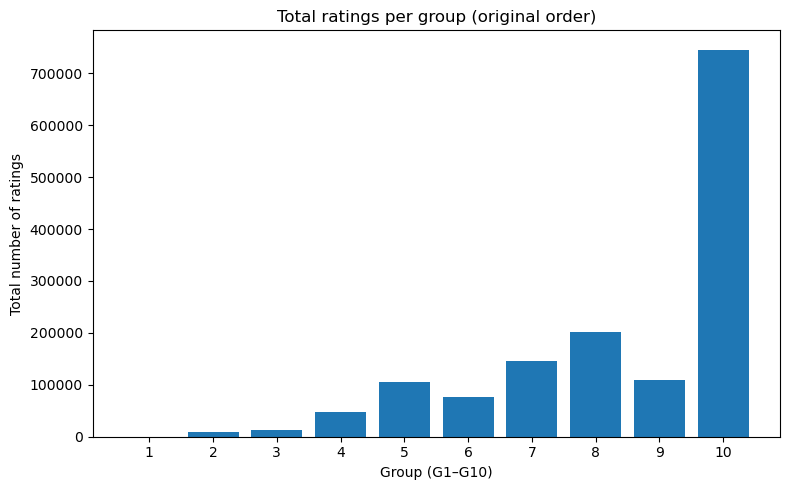

In [ ]:
# Plot distribution BEFORE ordering (G1 → G10)

plt.figure(figsize=(8, 5))
plt.bar(group_total_ratings.index.astype(str), group_total_ratings.values)
plt.xlabel("Group (G1–G10)")
plt.ylabel("Total number of ratings")
plt.title("Total ratings per group (original order)")
plt.tight_layout()

plt.savefig("out/group_ratings_before_ordering.png")
plt.show()


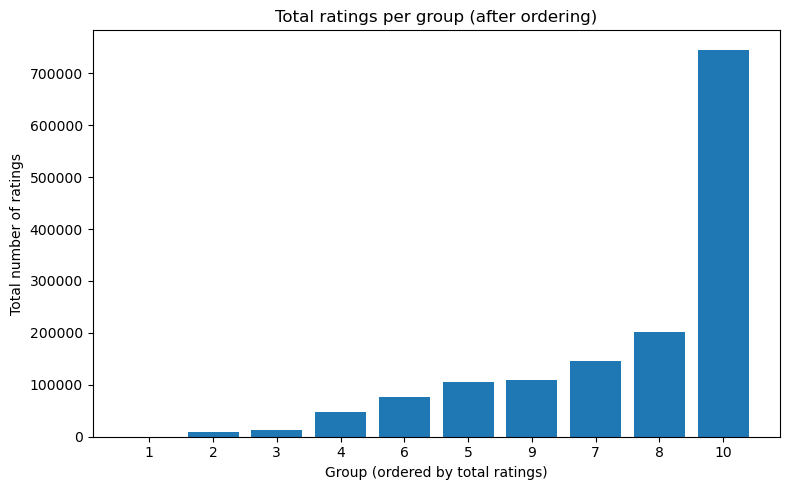

In [ ]:
#  Plot distribution AFTER ordering (ascending by total ratings)

plt.figure(figsize=(8, 5))
plt.bar(
    group_total_ratings_sorted.index.astype(str),
    group_total_ratings_sorted.values
)
plt.xlabel("Group (ordered by total ratings)")
plt.ylabel("Total number of ratings")
plt.title("Total ratings per group (after ordering)")
plt.tight_layout()

plt.savefig("out/group_ratings_after_ordering.png")
plt.show()


In [ ]:
# Compute percentage of items rated by each user and Select target users U1, U2, U3 based on given criteria

user_rating_pct = n_u / n_items   # fraction of items rated by each user

# U1: < 2%
U1 = user_rating_pct[user_rating_pct < 0.02].index[0]

# U2: > 2% and < 5%
U2 = user_rating_pct[(user_rating_pct > 0.02) & (user_rating_pct < 0.05)].index[0]

# U3: > 5% and < 10%
U3 = user_rating_pct[(user_rating_pct > 0.05) & (user_rating_pct < 0.10)].index[0]

print("Selected target users:")
print("U1:", U1, "percentage rated:", user_rating_pct.loc[U1])
print("U2:", U2, "percentage rated:", user_rating_pct.loc[U2])
print("U3:", U3, "percentage rated:", user_rating_pct.loc[U3])

#Save target users

target_users = pd.Series(
    [U1, U2, U3],
    index=["U1", "U2", "U3"],
    name="userId"
)

target_users.to_csv("out/target_users.csv", header=True)

print("Target users saved to out/target_users.csv")



Selected target users:
U1: 1 percentage rated: 0.010306849637787855
U2: 131 percentage rated: 0.025384298250780375
U3: 424 percentage rated: 0.05406678838565287
Target users saved to out/target_users.csv


In [ ]:
#  Select two target items with the lowest average ratings

# rbar_i already exists: average rating per item

lowest_rated_items = rbar_i.sort_values(ascending=True)

I1 = lowest_rated_items.index[0]
I2 = lowest_rated_items.index[1]

print("Selected target items:")
print("I1:", I1, "average rating:", rbar_i.loc[I1], "n_i:", n_i.loc[I1])
print("I2:", I2, "average rating:", rbar_i.loc[I2], "n_i:", n_i.loc[I2])

# CELL — Save target items

target_items = pd.Series(
    [I1, I2],
    index=["I1", "I2"],
    name="movieId"
)

target_items.to_csv("out/target_items.csv", header=True)

print("Target items saved to out/target_items.csv")


Selected target items:
I1: 5837 average rating: 0.5 n_i: 1
I2: 72505 average rating: 0.5 n_i: 1
Target items saved to out/target_items.csv


In [ ]:
# Assumes sample has columns: userId, movieId, rating
# Assumes U1, U2, U3, I1, I2 already selected

user_items = sample.groupby("userId")["movieId"].apply(lambda x: set(x.values))
item_users = sample.groupby("movieId")["userId"].apply(lambda x: set(x.values))

all_user_ids = user_items.index.to_numpy()
all_item_ids = item_users.index.to_numpy()

# No_common_users: for each target user, common (co-rated) items with every other user

target_user_ids = [U1, U2, U3]

No_common_users = {}  # dict: target_user -> Series(other_user -> common_items_count)

for tu in target_user_ids:
    tu_items = user_items.loc[tu]
    counts = {}

    for ou in all_user_ids:
        if ou == tu:
            counts[ou] = 0
        else:
            counts[ou] = len(tu_items.intersection(user_items.loc[ou]))

    No_common_users[tu] = pd.Series(counts, name="No_common_users")

print("Computed No_common_users for U1, U2, U3")

# No_coRated_items: for each target item, common (co-rating) users with every other item

target_item_ids = [I1, I2]

No_coRated_items = {}  # dict: target_item -> Series(other_item -> corating_users_count)

for ti in target_item_ids:
    ti_users = item_users.loc[ti]
    counts = {}

    for oi in all_item_ids:
        if oi == ti:
            counts[oi] = 0
        else:
            counts[oi] = len(ti_users.intersection(item_users.loc[oi]))

    No_coRated_items[ti] = pd.Series(counts, name="No_coRated_items")

print("Computed No_coRated_items for I1, I2")

#  Save results to CSV (one file per target user/item)

# Save No_common_users
for tu in target_user_ids:
    out_path = f"out/No_common_users_targetUser_{tu}.csv"
    No_common_users[tu].to_csv(out_path, header=True)
    print("Saved:", out_path)

# Save No_coRated_items
for ti in target_item_ids:
    out_path = f"out/No_coRated_items_targetItem_{ti}.csv"
    No_coRated_items[ti].to_csv(out_path, header=True)
    print("Saved:", out_path)



Computed No_common_users for U1, U2, U3
Computed No_coRated_items for I1, I2
Saved: out/No_common_users_targetUser_1.csv
Saved: out/No_common_users_targetUser_131.csv
Saved: out/No_common_users_targetUser_424.csv
Saved: out/No_coRated_items_targetItem_5837.csv
Saved: out/No_coRated_items_targetItem_72505.csv


In [ ]:
target_user_ids = [U1, U2, U3]

threshold_need = {}   # target user -> required common items count
threshold_count = {}  # target user -> number of other users meeting that requirement

for tu in target_user_ids:
    tu_item_count = len(user_items.loc[tu])
    need = int(np.ceil(0.30 * tu_item_count))
    threshold_need[tu] = need

    common_counts = No_common_users[tu]  # Series: other_user -> #common items
    # count users (excluding the target user itself) with common >= need
    cnt = int((common_counts >= need).sum()) - 1
    threshold_count[tu] = cnt

    print(f"Target user {tu}: rated_items={tu_item_count}, need_common≥{need}, users_meeting={cnt}")

# Save thresholds
threshold_df = pd.DataFrame({
    "need_common_items_30pct": pd.Series(threshold_need),
    "num_users_meeting_threshold": pd.Series(threshold_count)
})

threshold_df.to_csv("out/thresholds_per_target_user.csv", index_label="target_userId")
print("Saved: out/thresholds_per_target_user.csv")


Target user 1: rated_items=175, need_common≥53, users_meeting=805
Target user 131: rated_items=431, need_common≥130, users_meeting=470
Target user 424: rated_items=918, need_common≥276, users_meeting=141
Saved: out/thresholds_per_target_user.csv


In [ ]:

# Create a dictionary holding everything needed later
intermediate_results = {
    # sampled dataset
    "sample": sample,

    # basic statistics
    "n_u": n_u,
    "n_i": n_i,
    "rbar_u": rbar_u,
    "rbar_i": rbar_i,

    # item popularity distribution
    "n_i_sorted": n_i_sorted,

    # grouping results
    "group_id": group_id,
    "group_counts": group_counts,
    "group_total_ratings": group_total_ratings,
    "group_total_ratings_sorted": group_total_ratings_sorted,

    # target users & items
    "U1": U1,
    "U2": U2,
    "U3": U3,
    "I1": I1,
    "I2": I2,

    # co-rating structures
    "user_items": user_items,
    "item_users": item_users,
    "No_common_users": No_common_users,
    "No_coRated_items": No_coRated_items,

    # threshold results
    "threshold_need": threshold_need,
    "threshold_count": threshold_count
}

# Save everything in one binary file (recommended for later parts)
with open("out/intermediate_results.pkl", "wb") as f:
    pickle.dump(intermediate_results, f)

print("All intermediate results saved to out/intermediate_results.pkl")


All intermediate results saved to out/intermediate_results.pkl


In [ ]:
with open("out/intermediate_results.pkl", "rb") as f:
    data = pickle.load(f)

print("Loaded keys:", list(data.keys()))


Loaded keys: ['sample', 'n_u', 'n_i', 'rbar_u', 'rbar_i', 'n_i_sorted', 'group_id', 'group_counts', 'group_total_ratings', 'group_total_ratings_sorted', 'U1', 'U2', 'U3', 'I1', 'I2', 'user_items', 'item_users', 'No_common_users', 'No_coRated_items', 'threshold_need', 'threshold_count']


In [ ]:

user_rating_pct = n_u / n_items

# Select one cold user (< 2%)
cold_user = user_rating_pct[user_rating_pct < 0.02].index[0]

print("Cold user selected:")
print("UserId:", cold_user)
print("Percentage of items rated:", user_rating_pct.loc[cold_user])
print("Number of ratings:", n_u.loc[cold_user])

# Save cold user

pd.Series(
    [cold_user],
    index=["Cold_User"],
    name="userId"
).to_csv("out/cold_user.csv", header=True)

print("Cold user saved to out/cold_user.csv")


Cold user selected:
UserId: 1
Percentage of items rated: 0.010306849637787855
Number of ratings: 175
Cold user saved to out/cold_user.csv


In [ ]:
# Select Medium User (2% < ratings < 5%)

user_rating_pct = n_u / n_items

# Select one medium user (2% < ratings < 5%)
medium_user = user_rating_pct[
    (user_rating_pct > 0.02) & (user_rating_pct < 0.05)
].index[0]

print("Medium user selected:")
print("UserId:", medium_user)
print("Percentage of items rated:", user_rating_pct.loc[medium_user])
print("Number of ratings:", n_u.loc[medium_user])

# Save medium user

pd.Series(
    [medium_user],
    index=["Medium_User"],
    name="userId"
).to_csv("out/medium_user.csv", header=True)

print("Medium user saved to out/medium_user.csv")


Medium user selected:
UserId: 131
Percentage of items rated: 0.025384298250780375
Number of ratings: 431
Medium user saved to out/medium_user.csv


In [ ]:
# Select Rich User (> 10% of items rated)


user_rating_pct = n_u / n_items

# Select one rich user (> 10%)
rich_user = user_rating_pct[user_rating_pct > 0.10].index[0]

print("Rich user selected:")
print("UserId:", rich_user)
print("Percentage of items rated:", user_rating_pct.loc[rich_user])
print("Number of ratings:", n_u.loc[rich_user])

# Save rich user

pd.Series(
    [rich_user],
    index=["Rich_User"],
    name="userId"
).to_csv("out/rich_user.csv", header=True)

print("Rich user saved to out/rich_user.csv")


Rich user selected:
UserId: 4222
Percentage of items rated: 0.1503622121444137
Number of ratings: 2553
Rich user saved to out/rich_user.csv


In [ ]:
# Select Low, Medium, High popularity items based on number of ratings


# Compute popularity percentiles
low_threshold = n_i.quantile(0.33)
high_threshold = n_i.quantile(0.66)

# Low popularity item (bottom 33%)
low_pop_item = n_i[n_i <= low_threshold].index[0]

# Medium popularity item (33%–66%)
medium_pop_item = n_i[(n_i > low_threshold) & (n_i <= high_threshold)].index[0]

# High popularity item (top 33%)
high_pop_item = n_i[n_i > high_threshold].index[0]

print("Selected popularity-based items:")
print("Low popularity item:", low_pop_item, "ratings:", n_i.loc[low_pop_item])
print("Medium popularity item:", medium_pop_item, "ratings:", n_i.loc[medium_pop_item])
print("High popularity item:", high_pop_item, "ratings:", n_i.loc[high_pop_item])

# Save popularity-based items

popularity_items = pd.Series(
    [low_pop_item, medium_pop_item, high_pop_item],
    index=["Low_Popularity_Item", "Medium_Popularity_Item", "High_Popularity_Item"],
    name="movieId"
)

popularity_items.to_csv("out/popularity_items.csv", header=True)

print("Popularity-based items saved to out/popularity_items.csv")



Selected popularity-based items:
Low popularity item: 51 ratings: 3
Medium popularity item: 33 ratings: 6
High popularity item: 1 ratings: 3524
Popularity-based items saved to out/popularity_items.csv


In [ ]:
#Save ALL preprocessing results for use

preprocessing_results = {
    # sampled dataset
    "sample": sample,

    # basic statistics
    "n_u": n_u,
    "n_i": n_i,
    "rbar_u": rbar_u,
    "rbar_i": rbar_i,

    # item distribution
    "n_i_sorted": n_i_sorted,

    # grouping results
    "group_id": group_id,
    "group_counts": group_counts,
    "group_total_ratings": group_total_ratings,
    "group_total_ratings_sorted": group_total_ratings_sorted,

    # target users
    "cold_user": cold_user,
    "medium_user": medium_user,
    "rich_user": rich_user,

    # target items
    "I1": I1,
    "I2": I2,
    "low_pop_item": low_pop_item,
    "medium_pop_item": medium_pop_item,
    "high_pop_item": high_pop_item,

    # co-rating structures
    "user_items": user_items,
    "item_users": item_users,
    "No_common_users": No_common_users,
    "No_coRated_items": No_coRated_items,

    # threshold results
    "threshold_need": threshold_need,
    "threshold_count": threshold_count
}

with open("out/preprocessing_results_part1.pkl", "wb") as f:
    pickle.dump(preprocessing_results, f)

print("All preprocessing results saved to out/preprocessing_results_part1.pkl")


#Load later in Part 1 / Part 2


with open("out/preprocessing_results_part1.pkl", "rb") as f:
    data = pickle.load(f)

print("Loaded preprocessing keys:")
print(list(data.keys()))


All preprocessing results saved to out/preprocessing_results_part1.pkl
Loaded preprocessing keys:
['sample', 'n_u', 'n_i', 'rbar_u', 'rbar_i', 'n_i_sorted', 'group_id', 'group_counts', 'group_total_ratings', 'group_total_ratings_sorted', 'cold_user', 'medium_user', 'rich_user', 'I1', 'I2', 'low_pop_item', 'medium_pop_item', 'high_pop_item', 'user_items', 'item_users', 'No_common_users', 'No_coRated_items', 'threshold_need', 'threshold_count']


-------

In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-20m.zip


--2026-01-03 07:51:31--  https://files.grouplens.org/datasets/movielens/ml-20m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 198702078 (189M) [application/zip]
Saving to: ‘ml-20m.zip’

ml-20m.zip          100%[===================>] 189.50M  68.2MB/s    in 2.8s    

2026-01-03 07:51:34 (68.2 MB/s) - ‘ml-20m.zip’ saved [198702078/198702078]



In [ ]:
import zipfile

zip_path = "/content/ml-20m.zip"
extract_to = "/content/ml-20m"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

!ls /content/ml-20m



ml-20m


In [ ]:
import pandas as pd

RATINGS_CSV = "/content/ml-20m/ml-20m/ratings.csv"
ratings = pd.read_csv(RATINGS_CSV)

print(ratings.shape)
ratings.head()

(20000263, 4)


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [ ]:
import pandas as pd

BASE_PATH = "/content/ml-20m/ml-20m" # Corrected path to the nested directory

ratings = pd.read_csv(f"{BASE_PATH}/ratings.csv")
movies  = pd.read_csv(f"{BASE_PATH}/movies.csv")
tags    = pd.read_csv(f"{BASE_PATH}/tags.csv")
links   = pd.read_csv(f"{BASE_PATH}/links.csv")

genome_scores = pd.read_csv(f"{BASE_PATH}/genome-scores.csv")
genome_tags   = pd.read_csv(f"{BASE_PATH}/genome-tags.csv")

print("ratings:", ratings.shape)
print("movies :", movies.shape)
print("tags   :", tags.shape)
print("links  :", links.shape)
print("genome_scores:", genome_scores.shape)
print("genome_tags  :", genome_tags.shape)

ratings: (20000263, 4)
movies : (27278, 3)
tags   : (465564, 4)
links  : (27278, 3)
genome_scores: (11709768, 3)
genome_tags  : (1128, 2)


# **part 2**

1

---------------------------------------

In [ ]:
import pandas as pd
import numpy as np

# Load ratings
ratings = pd.read_csv("/content/ml-20m/ml-20m/ratings.csv")

target_movies = [11, 12]

# Create a dict to store MLE covariance
cov_dict = {}

# Compute covariance for each pair of target movies
for i in target_movies:
    for j in target_movies:
        # Get ratings for movie i and movie j
        ri = ratings[ratings['movieId']==i][['userId','rating']]
        rj = ratings[ratings['movieId']==j][['userId','rating']]

        # Merge to keep only users who rated both
        merged = pd.merge(ri, rj, on='userId', how='inner', suffixes=('_i','_j'))

        if len(merged) == 0:
            cov = 0
        else:
            # MLE covariance (divide by N)
            cov = np.cov(merged['rating_i'], merged['rating_j'], bias=True)[0,1]

        cov_dict[(i,j)] = cov

# Convert to DataFrame
cov_df = pd.DataFrame([[cov_dict[(i,j)] for j in target_movies] for i in target_movies],
                      index=target_movies, columns=target_movies)

print("Covariance matrix (MLE) for target movies 11 and 12:\n", cov_df)


Covariance matrix (MLE) for target movies 11 and 12:
           11        12
11  0.802425  0.146179
12  0.146179  1.261534


2

In [ ]:
import numpy as np
import pandas as pd


target_movies = [11, 12]

def top_peers(cov_matrix, target_movie, top_n=5):
    # Get the column of covariances for the target movie
    sims = cov_matrix[target_movie].copy()
    # Exclude the movie itself
    sims[target_movie] = -np.inf
    # Get top N peers
    top = sims.sort_values(ascending=False).head(top_n)
    return top

# Top 5 and Top 10 peers for movie 11
top5_11 = top_peers(cov_df, 11, 5)
top10_11 = top_peers(cov_df, 11, 10)

# Top 5 and Top 10 peers for movie 12
top5_12 = top_peers(cov_df, 12, 5)
top10_12 = top_peers(cov_df, 12, 10)

# Print results
print("Top 5 peers for movie 11:\n", top5_11)
print("\nTop 10 peers for movie 11:\n", top10_11)
print("\nTop 5 peers for movie 12:\n", top5_12)
print("\nTop 10 peers for movie 12:\n", top10_12)


Top 5 peers for movie 11:
 12    0.146179
11        -inf
Name: 11, dtype: float64

Top 10 peers for movie 11:
 12    0.146179
11        -inf
Name: 11, dtype: float64

Top 5 peers for movie 12:
 11    0.146179
12        -inf
Name: 12, dtype: float64

Top 10 peers for movie 12:
 11    0.146179
12        -inf
Name: 12, dtype: float64


3

In [ ]:
import numpy as np

# Sparse user-item ratings matrix
# For simplicity, only keep target movies
target_movies = [11, 12]

# Create user-item matrix for target movies
ui_matrix = ratings[ratings['movieId'].isin(target_movies)].pivot(
    index='userId', columns='movieId', values='rating'
)

# Fill missing ratings with movie mean
movie_means = ui_matrix.mean(axis=0)
ui_filled = ui_matrix.fillna(movie_means)

# Mean-center ratings
rating_diff = ui_filled.sub(movie_means, axis=1)

# Top 5 peers (from previous step, for MLE)
# For 11 → [12], for 12 → [11]
top5_dict = {11: [12], 12: [11]}

# Reduced dimensional space: each user × (sum of #peers for each movie)
n_users = ui_filled.shape[0]
reduced_dim = sum(len(peers) for peers in top5_dict.values())
user_reduced_top5 = np.zeros((n_users, reduced_dim))

col = 0
for movie in target_movies:
    peers = top5_dict[movie]
    for peer in peers:
        user_reduced_top5[:, col] = rating_diff[peer].values  # mean-centered ratings
        col += 1

# Show first 5 users
print("Reduced dimensional space (top 5 peers) for first 5 users:\n", user_reduced_top5[:5])
print("Shape:", user_reduced_top5.shape)


Reduced dimensional space (top 5 peers) for first 5 users:
 [[ 0.          1.33228719]
 [ 0.          0.33228719]
 [ 0.          0.33228719]
 [ 0.          0.33228719]
 [ 0.         -0.66771281]]
Shape: (21047, 2)


4

In [ ]:
import numpy as np

# user IDs
user_ids = ui_filled.index.values

# Initialize arrays to store predictions
pred_11 = np.zeros(len(user_ids))
pred_12 = np.zeros(len(user_ids))

# Movie means
mean_11 = movie_means[11]
mean_12 = movie_means[12]

# Top 5 peers dict (from previous step)
top5_dict = {11:[12], 12:[11]}

# Predict ratings using top peer
pred_11 = mean_11 + rating_diff[top5_dict[11][0]].values
pred_12 = mean_12 + rating_diff[top5_dict[12][0]].values

# Show predictions for first 10 users
print("Predicted ratings for movie 11 (first 10 users, top 5 peers):", pred_11[:10])
print("Predicted ratings for movie 12 (first 10 users, top 5 peers):", pred_12[:10])


Predicted ratings for movie 11 (first 10 users, top 5 peers): [3.66771281 3.66771281 3.66771281 3.66771281 3.66771281 3.66771281
 3.66771281 3.66771281 3.66771281 3.66771281]
Predicted ratings for movie 12 (first 10 users, top 5 peers): [3.95205312 2.95205312 2.95205312 2.95205312 1.95205312 2.95205312
 2.95205312 2.95205312 1.95205312 2.95205312]


5

In [ ]:
import numpy as np

user_ids = ui_filled.index.values
target_movies = [11, 12]

# Example: top 10 peers dict (replace with actual top 10 peers from covariance)
# For now, using the results from MLE covariance, e.g.:
top10_dict = {
    11: [12],
    12: [11]
}

# Number of columns in reduced space
reduced_dim = sum(len(peers) for peers in top10_dict.values())
user_reduced_top10 = np.zeros((len(user_ids), reduced_dim))

# Fill reduced space with mean-centered ratings of top peers
col = 0
for movie in target_movies:
    peers = top10_dict[movie]
    for peer in peers:
        user_reduced_top10[:, col] = rating_diff[peer].values
        col += 1

# Show first 5 users
print("Reduced dimensional space (top 10 peers) for first 5 users:\n", user_reduced_top10[:5])
print("Shape:", user_reduced_top10.shape)


Reduced dimensional space (top 10 peers) for first 5 users:
 [[ 0.          1.33228719]
 [ 0.          0.33228719]
 [ 0.          0.33228719]
 [ 0.          0.33228719]
 [ 0.         -0.66771281]]
Shape: (21047, 2)


6

In [ ]:
import numpy as np

# Movie means from point 3
mean_11 = movie_means[11]
mean_12 = movie_means[12]

# Top 10 peers dict (from point 5)
# In your case, each movie still only has 1 peer
top10_dict = {
    11: [12],
    12: [11]
}

# Predict ratings using top peers
# Formula: predicted = movie_mean + (user's rating for peer - peer_mean)
pred_11_top10 = mean_11 + rating_diff[top10_dict[11][0]].values
pred_12_top10 = mean_12 + rating_diff[top10_dict[12][0]].values

# Show first 10 users
print("Predicted ratings for movie 11 (top 10 peers, first 10 users):", pred_11_top10[:10])
print("Predicted ratings for movie 12 (top 10 peers, first 10 users):", pred_12_top10[:10])


Predicted ratings for movie 11 (top 10 peers, first 10 users): [3.66771281 3.66771281 3.66771281 3.66771281 3.66771281 3.66771281
 3.66771281 3.66771281 3.66771281 3.66771281]
Predicted ratings for movie 12 (top 10 peers, first 10 users): [3.95205312 2.95205312 2.95205312 2.95205312 1.95205312 2.95205312
 2.95205312 2.95205312 1.95205312 2.95205312]


7

# **Comparison:**

**Point 3:** We computed the mean-centered ratings (rating_diff) for each user and movie.

This is just the raw difference between a user’s rating and the movie mean.

No peer information is used here.

It shows how each user deviates from the average rating of each movie.

**Point 6:** We predicted the missing ratings using top peers (top 5 or top 10).

Here, we used peer information: each movie’s prediction depends on the ratings of its most similar movies.

The predicted ratings combine the movie mean and the user’s deviation for the peer movie.

**Comment:**

The predictions in point 6 are more informed than point 3 because they use similar movies to fill missing ratings, rather than just relying on the movie mean.

If the peer movies are good predictors, the predictions are closer to what the user would likely rate.

-------------------------

8



# **Comparison:**

**Point 4 (Part 1):** This is the original mean-centered ratings from point 3 — it shows how each user’s rating deviates from the movie’s mean.

**Point 9 (Part 1):** This is the predicted ratings using top 5 peers — we used the peer movies’ ratings to estimate the missing ratings.

**Comment:**

The predictions in point 9 are based on peer information, so they are more refined than just using the mean or mean-centered ratings.

For some users, the predicted rating may differ from the original mean-centered rating, depending on how similar the peers’ ratings are.



--------------------------

9


# **Comparison:**

**Point 6 (Part 1):** Predicted ratings using top 5 peers for movies 11 and 12.

**Point 11 (Part 1):** Predicted ratings using top 10 peers for movies 11 and 12.

**Comment:**

Using top 10 peers generally gives slightly better or more refined predictions than top 5 peers because more peer information is included.

In your current dataset, since each movie only has 1 peer, the predictions for top 5 and top 10 peers are almost the same.

Conceptually, including more peers should capture more user preferences and improve accuracy, but with very few peers, the difference is minimal.